In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost 
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
)



In [ ]:

df = pd.read_csv('Copia de data_merged.csv')



In [ ]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000

def categorize_popularity(popularity):
    if popularity == 0:
        return 0 #no popular
    elif popularity<=20:
        return 1 # baja
    elif popularity <=40:
        return 2 # media
    return 3 # alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['no popular','Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")



In [ ]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

In [ ]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



In [ ]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

In [ ]:

selector = SelectKBest(score_func=f_classif,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.sort(total_score)[::-1]
plt.figure(figsize=(10,8))
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [ ]:
selector = SelectKBest(score_func=f_classif,k=6)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


In [320]:
_X=X[select]
y =y_multiclass_3

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)



In [321]:
mask_bajas = (y_train_reduce == 0) | (y_train_reduce == 1)
X_low ,y_low = X_train_reduce[mask_bajas],y_train_reduce[mask_bajas]
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(
    X_low, y_low, 
    test_size=0.2, 
    stratify=y_low,
    random_state=42
)

In [322]:
mask_alta = (y_train_reduce == 2) | (y_train_reduce== 3)
X_alta, y_alta = X_train_reduce[mask_alta],y_train_reduce[mask_alta]
X_train_alta, X_test_alta, y_train_alta, y_test_alta = train_test_split(
    X_alta, y_alta, 
    test_size=0.2, 
    stratify=y_alta,
    random_state=42
)

In [323]:
def _create_pipeline():
        return Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', RandomForestClassifier(max_depth=20,n_estimators=300, class_weight='balanced'))
        ])

[59010 78774]
Entrenando divisor de clase popular y no popular
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     14752
           1       0.96      0.94      0.95     19694

    accuracy                           0.94     34446
   macro avg       0.94      0.94      0.94     34446
weighted avg       0.94      0.94      0.94     34446



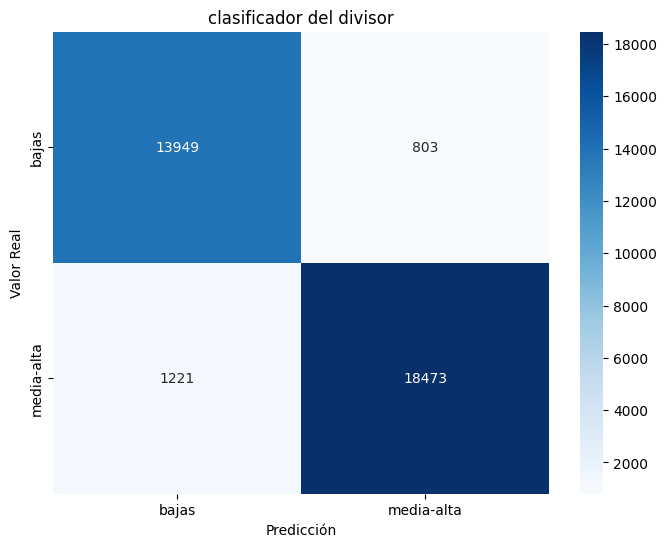

In [ ]:
y_divisor = np.where(y_train_reduce <= 1, 0, 1)
y_divisor_test = np.where(y_test_reduce <= 1, 0, 1)
print("Entrenando divisor de clase popular y no popular")
divisor_ = _create_pipeline()

divisor_.fit(X_train_reduce,y_divisor )
predict_div = divisor_.predict(X_test_reduce)
r = classification_report(y_divisor_test, predict_div)
print(r)
cm = confusion_matrix(y_divisor_test, predict_div)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['bajas','media-alta'],
                        yticklabels=['bajas','media-alta'])

plt.ylabel('Valor Real')
plt.title("clasificador del divisor")
plt.xlabel('Predicción')
plt.show()


              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7946
           1       0.93      0.92      0.92      6807

    accuracy                           0.93     14753
   macro avg       0.93      0.93      0.93     14753
weighted avg       0.93      0.93      0.93     14753



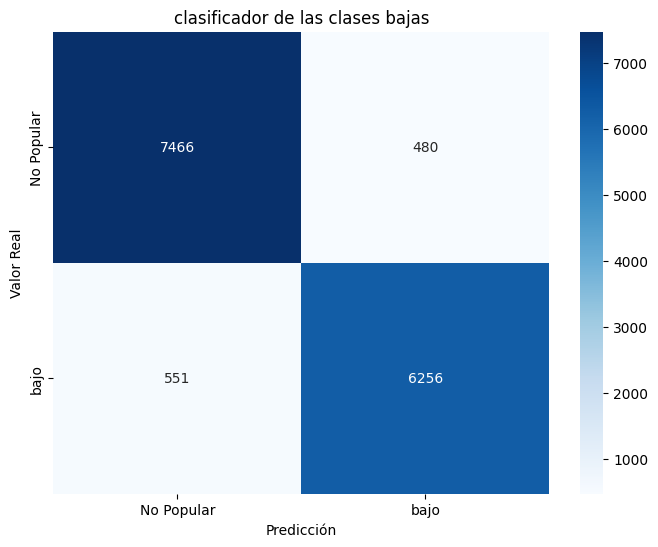

In [310]:
expert_low_ = _create_pipeline()
expert_low_.fit(X_train_low, y_train_low)
predict_bajas = expert_low_.predict(X_test_low)
r = classification_report(y_test_low, predict_bajas)
print(r)
cm = confusion_matrix(y_test_low, predict_bajas)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['No Popular', 'bajo',],
                        yticklabels=['No Popular', 'bajo',])

plt.ylabel('Valor Real')
plt.title("clasificador de las clases bajas")
plt.xlabel('Predicción')
plt.show()

              precision    recall  f1-score   support

           2       0.77      0.85      0.81     10207
           3       0.82      0.73      0.78      9487

    accuracy                           0.80     19694
   macro avg       0.80      0.79      0.79     19694
weighted avg       0.80      0.80      0.79     19694



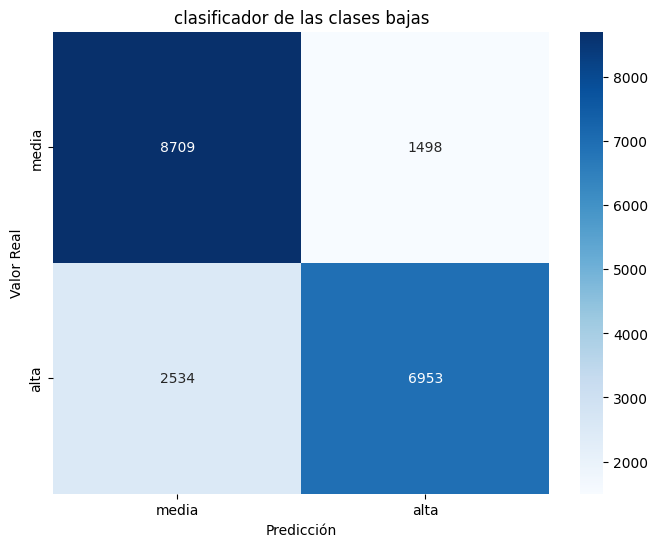

In [315]:
expert_alta = _create_pipeline()
expert_alta.fit(X_train_alta, y_train_alta)
predict_alta = expert_alta.predict(X_test_alta)
r = classification_report(y_test_alta, predict_alta)
print(r)
cm = confusion_matrix(y_test_alta, predict_alta)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['media', 'alta',],
                        yticklabels=['media', 'alta',])

plt.ylabel('Valor Real')
plt.title("clasificador de las clases bajas")
plt.xlabel('Predicción')
plt.show()

In [324]:
result = np.zeros(len(X_test_reduce),dtype=int)

mask_low_model= (predict_div==1)
X_ = X_test_reduce[mask_low_model]
r1=expert_alta.predict(X_)
result[mask_low_model]=r1
mask_alta_model= (predict_div==0)
X__ = X_test_reduce[mask_alta_model]
r2= expert_low_.predict(X__)
result[mask_alta_model]=r2

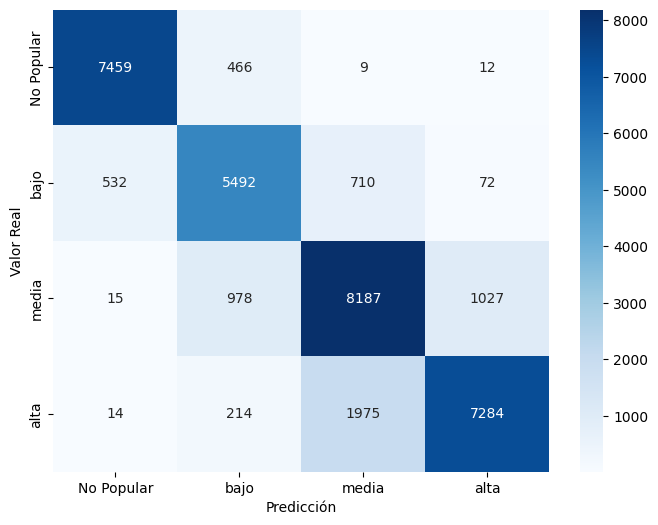

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7946
           1       0.77      0.81      0.79      6806
           2       0.75      0.80      0.78     10207
           3       0.87      0.77      0.81      9487

    accuracy                           0.83     34446
   macro avg       0.83      0.83      0.83     34446
weighted avg       0.83      0.83      0.83     34446



In [327]:
cm = confusion_matrix(y_test_reduce, result)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()
r = classification_report(y_test_reduce, result)
print(r)